In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading and Merging

In [2]:
df = pd.read_csv('./data/partidos.csv')
df_ranking = pd.read_csv('./data/ranking_fifa.csv')
df_transfermarkt = pd.read_csv('./data/transfermarkt.csv')

C:\Users\javie\AppData\Local\Temp\ipykernel_27344\1432938540.py:1: DtypeWarning: Columns (0: Pases_largos_Local, 1: Pases_largos_Visitante, 2: Pases_en_el_tercio_final_Local, 3: Pases_en_el_tercio_final_Visitante, 4: Centros_Local, 5: Centros_Visitante, 6: Entradas_Local, 7: Entradas_Visitante, 8: 2Córneres2_Local, 9: 2Córneres2_Visitante, 10: 2Córneres3_Local, 11: 2Córneres3_Visitante, 12: 4Córneres4_Local, 13: 4Córneres4_Visitante, 14: 0Córneres8_Local, 15: 0Córneres8_Visitante, 16: 3Córneres1_Local, 17: 3Córneres1_Visitante, 18: 5Córneres6_Local, 19: 5Córneres6_Visitante, 20: 3Córneres6_Local, 21: 3Córneres6_Visitante, 22: Gol1_-_0_Local, 23: Gol1_-_0_Visitante, 24: 1_-_1Gol_Local, 25: 1_-_1Gol_Visitante, 26: Sustitución_-_Entra_Local, 27: Sustitución_-_Entra_Visitante, 28: 1_-_2Gol_Local, 29: 1_-_2Gol_Visitante, 30: 2Córneres16_Local, 31: 2Córneres16_Visitante, 32: 7Córneres5_Local, 33: 7Córneres5_Visitante, 34: 5Córneres4_Local, 35: 5Córneres4_Visitante, 36: 0_-_2Gol_Local, 37: 0_

In [3]:
# Check no duplicates
print(df.shape)
df.drop_duplicates(subset=['URL', 'Fecha', 'Equipo_Local', 'Equipo_Visitante'], keep='last', inplace=True)
print(df.shape)

(3316, 2778)
(3316, 2778)


## Dataset Overview

Summary of the raw dataset after deduplication: shape, variable types, and temporal coverage.

In [4]:
# --- Tabla 1: Resumen del dataset crudo ---
print(f'Shape: {df.shape[0]} partidos x {df.shape[1]} variables')
print(f'Rango temporal: {df["Fecha"].min()} - {df["Fecha"].max()}')

tipos = df.dtypes.value_counts()
print('\nTable 1. Variable types in raw dataset')
for t, n in tipos.items():
    print(f'  {str(t):15s}: {n} columns')

print(f'\nTotal missing values: {df.isna().sum().sum():,}')
print(f'Overall missing rate: {df.isna().mean().mean():.1%}')

Shape: 3316 partidos x 2778 variables
Rango temporal: 01.01.2026 14:00 - 31.12.2025 20:00

Table 1. Variable types in raw dataset
  str            : 2720 columns
  float64        : 57 columns
  int64          : 1 columns

Total missing values: 9,090,640
Overall missing rate: 98.7%


### Todos los partidos

Para la nueva pregunta de investigación (*¿Qué estadísticas de rendimiento predicen el resultado?*), mantenemos todos los partidos disponibles, sin filtrar por equipos del Mundial.

In [5]:
# Mantenemos todos los partidos - no filtramos por equipos del Mundial
print(df.shape)

(3316, 2778)


## Join ranking FIFA

Vamos a crear un diccionario para poder hacer el join de los datos de FlashScore y el ranking FIFA. 

In [6]:
# CLAVE = Nombre en df_ranking (El que queremos cambiar)
# VALOR = Nombre en df_partidos (El que queremos conservar)
mapeo_paises = {
    'EEUU': 'EE. UU.',
    'RI de Irán': 'Irán',
    'República de Corea': 'Corea del Sur',
    'RD del Congo': 'RD Congo',
    'Bosnia y Herzegovina': 'Bosnia-Herzegovina',
    'Baréin': 'Bahréin',
    'RP China': 'China',
    'República Kirguisa': 'Kirguistán',
    'Kazajstán': 'Kazajistán',
    'RDP de Corea': 'Corea del Norte',
    'Guinea-Bissáu': 'Guinea-Bisáu',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Hong Kong, China': 'Hong Kong',
    'Myanmar': 'Birmania',
    'Esuatini': 'Eswatini',
    'Chinese Taipei': 'China Taipei',
    'Bangladesh': 'Bangladés',
    'Samoa Estadounidense': 'Samoa Americana',
    'Brunéi Darussalam': 'Brunéi',
    'República de Irlanda': 'Irlanda',
    'Qatar': 'Catar',
    'Turcas y Caicos': 'Islas Turcas y Caicos',
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'Comoras': 'Comores'
}

# Aplicar el reemplazo en la columna del df_ranking
df_ranking['País'] = df_ranking['País'].replace(mapeo_paises)

# Comprobar si ha quedado algún país "huérfano"
paises_df = set(df['Equipo_Local'].unique()).union(set(df['Equipo_Visitante'].unique()))
paises_ranking = set(df_ranking['País'].unique())

huérfanos = paises_df - paises_ranking

if huérfanos:
    print(f"ATENCIÓN: Hay {len(huérfanos)} países que NO tienen ranking FIFA asociado:")
    print(sorted(list(huérfanos)))
else:
    print("Éxito! Todos los países de tus partidos tienen su correspondencia exacta en el ranking FIFA.")

ATENCIÓN: Hay 160 países que NO tienen ranking FIFA asociado:
['Afganistán Sub-20', 'Albania Sub-21', 'Alemania Sub-17', 'Alemania Sub-18', 'Alemania Sub-19', 'Arabia Saudí Sub-20', 'Argelia Sub-20', 'Argelia Sub-23', 'Argentina Sub-17', 'Argentina Sub-20', 'Australia Sub-17', 'Australia Sub-20', 'Austria Sub-17', 'Austria Sub-18', 'Bonaire', 'Bosnia-Herzegovina Sub-19', 'Brasil Sub-20', 'Bulgaria Sub-19', 'Bután Sub-23', 'Bélgica Sub-17', 'Bélgica Sub-21', 'Catar Sub-17', 'Catar Sub-20', 'Catar Sub-23', 'Chile Sub-17', 'Chile Sub-20', 'China Sub-20', 'China Sub-23', 'Chipre Sub-19', 'Colombia Sub-20', 'Corea del Norte Sub-23', 'Corea del Sur Sub-17', 'Corea del Sur Sub-23', 'Costa Rica Sub-20', 'Costa de Marfil Sub-20', 'Costa de Marfil Sub-23', 'Croacia Sub-17', 'Croacia Sub-19', 'EE. UU. Sub-18', 'EE. UU. Sub-19', 'EE. UU. Sub-20', 'EE. UU. Sub-21', 'Ecuador Sub-17', 'Egipto Sub-19', 'Egipto Sub-20', 'Emiratos Árabes Unidos Sub-19', 'Emiratos Árabes Unidos Sub-20', 'Emiratos Árabes 

In [7]:
print(df_ranking.head())


         País  Puntuación       Fecha
0     Francia     1877.32  01-04-2026
1      España     1876.40  01-04-2026
2   Argentina     1874.81  01-04-2026
3  Inglaterra     1825.97  01-04-2026
4    Portugal     1763.83  01-04-2026


Unificamos las fechas para el JOIN.

In [8]:
# Gestion de la fecha
# Convierte la columna al formato datetime de Pandas reconociendo los puntos y la hora
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y %H:%M')

# (Opcional) Si la hora no te aporta nada y quieres quedarte solo con la fecha limpia (YYYY-MM-DD)
df['Fecha'] = df['Fecha'].dt.normalize()
##df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

# Cambiamos el formato de la fecha a YYYY-MM-DD
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha'], format='%d-%m-%Y')
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha']).dt.strftime('%Y-%m-%d')

# Forzar la conversión de ambas columnas a datetime puro
df['Fecha'] = pd.to_datetime(df['Fecha']).dt.tz_localize(None)
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha']).dt.tz_localize(None)

In [9]:
# ORDENAR por fecha (Obligatorio para merge_asof)
df = df.sort_values('Fecha').reset_index(drop=True)
df_ranking = df_ranking.sort_values('Fecha').reset_index(drop=True)

# ==========================================
# PASO 1: Cruzar ranking del EQUIPO LOCAL
# ==========================================
df = pd.merge_asof(
    df, 
    df_ranking,
    on='Fecha',               # Como se llama igual en ambos, usamos simplemente 'on'
    left_by='Equipo_Local',   
    right_by='País',          
    direction='backward',     
    allow_exact_matches=False 
)

# Renombramos SOLO los datos del ranking, dejando la 'Fecha' intacta
df = df.rename(columns={
    'Puntuación': 'Puntos_Local'  # O la variable que tengas de puntos
})

# ==========================================
# PASO 2: Cruzar ranking del EQUIPO VISITANTE
# ==========================================
df = pd.merge_asof(
    df, 
    df_ranking,
    on='Fecha',               # La columna 'Fecha' sigue ahí, lista para usarse
    left_by='Equipo_Visitante',
    right_by='País',
    direction='backward',
    allow_exact_matches=False 
)

# Renombramos los datos del Visitante
df = df.rename(columns={
    'Puntuación': 'Puntos_Visitante'
})

# Opcional: Como el 'País' del df_ranking se nos pegará dos veces, lo limpiamos
columnas_a_borrar = [col for col in df.columns if 'País' in col]
print(columnas_a_borrar)
df = df.drop(columns=columnas_a_borrar)

# Comprobamos el JOIN
print(df[['Fecha', 'Equipo_Local', 'Puntos_Local', 'Equipo_Visitante', 'Puntos_Visitante']].head())

['País_x', 'País_y']
       Fecha Equipo_Local  Puntos_Local Equipo_Visitante  Puntos_Visitante
0 2019-06-06     Mongolia         915.0           Brunéi             903.0
1 2019-06-06        Macao         925.0        Sri Lanka             886.0
2 2019-06-06         Laos         923.0        Bangladés             907.0
3 2019-06-06      Camboya         970.0         Pakistán             888.0
4 2019-06-06        Bután         917.0             Guam             907.0


## Join Valor de Mercado

In [10]:
df_transfermarkt.head()

,Equipo,Valor_Mercado_Millones_Eur
0,Francia,58.58
1,Inglaterra,52.43
2,España,47.03
3,Portugal,38.67
4,Alemania,36.42


In [11]:
diccionario_Transfermarkt = {
    'Estados Unidos': 'EE. UU.',
    'Chequia': 'República Checa',
    'República Democrática del Congo': 'RD Congo',
    'Arabia Saudita': 'Arabia Saudí',
    'Malí': 'Mali',
    'Comoras': 'Comores',
    'Baréin': 'Bahréin',
    'Myanmar': 'Birmania',
    'República del Congo': 'Congo',
    'China Taipéi': 'China Taipei',
    'Esuatini': 'Eswatini',
    
    # Prevención para islas pequeñas (muy comunes al cruzar estos datos)
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Brunéi Darussalam': 'Brunéi',
    'Islas Vírgenes de los Estados Unidos': 'Islas Vírgenes Estadounidenses'
}

# Reemplaza los nombres de Transfermarkt por los tuyos
df_transfermarkt['Equipo'] = df_transfermarkt['Equipo'].replace(diccionario_Transfermarkt)

In [12]:
# ==========================================
# PASO 1: Cruzar valor del EQUIPO LOCAL
# ==========================================
df = pd.merge(
    df, 
    df_transfermarkt,        
    left_on='Equipo_Local',   
    right_on='Equipo',       
    how='left'               
)

# Renombramos la columna del valor local y eliminamos la columna 'Equipo' sobrante
df = df.rename(columns={
    'Valor_Mercado_Millones_Eur': 'Valor_Mercado_Millones_Eur_Local'  
}).drop(columns=['Equipo'])

# ==========================================
# PASO 2: Cruzar valor del EQUIPO VISITANTE
# ==========================================
df = pd.merge(
    df, 
    df_transfermarkt,        
    left_on='Equipo_Visitante', 
    right_on='Equipo',     
    how='left'
)

# Renombramos la columna del valor visitante y eliminamos la columna 'Equipo' sobrante
df = df.rename(columns={
    'Valor_Mercado_Millones_Eur': 'Valor_Mercado_Millones_Eur_Visitante'
}).drop(columns=['Equipo'])

# Comprobamos el JOIN 
print(df[['Fecha', 'Equipo_Local', 'Valor_Mercado_Millones_Eur_Local', 'Equipo_Visitante', 'Valor_Mercado_Millones_Eur_Visitante']].head())

       Fecha Equipo_Local  Valor_Mercado_Millones_Eur_Local Equipo_Visitante  \
0 2019-06-06     Mongolia                             0.024           Brunéi   
1 2019-06-06        Macao                             0.016        Sri Lanka   
2 2019-06-06         Laos                             0.057        Bangladés   
3 2019-06-06      Camboya                             0.099         Pakistán   
4 2019-06-06        Bután                             0.037             Guam   

   Valor_Mercado_Millones_Eur_Visitante  
0                                 0.035  
1                                 0.040  
2                                 0.315  
3                                 0.154  
4                                 0.010  


## Datos Continente

Vamos a agrupar los países por continetne para poder utilizar esta variable para modelizar (no es lo mismo enfrentarte normalmente a equipos de África que de Europa).

In [13]:
mapa_continentes = {
    # EUROPA (UEFA)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa',
    
    # SUDAMÉRICA (CONMEBOL)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',
    
    # NORTEAMÉRICA Y CARIBE (CONCACAF)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',
    
    # ÁFRICA (CAF)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa',
    
    # ASIA (AFC) - Nota: Australia compite deportivamente en Asia
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia'
}

In [14]:
# Aplicamos el diccionario para crear la nueva columna
df['Continente_Local'] = df['Equipo_Local'].map(mapa_continentes)
df['Continente_Visitante'] = df['Equipo_Visitante'].map(mapa_continentes)

In [15]:
print(df['Continente_Local'].value_counts())

Continente_Local
Europa          416
Asia            218
Africa          171
Sudamérica      151
Norteamérica    119
Name: count, dtype: int64


# Data Cleaning

In [16]:
print(df.shape)

# Definimos las condiciones: queremos las filas que NO (~) contengan "sub" (eliminar sub20, sub17, etc)
# Usamos na=False por si alguna celda está vacía, para que no de error
filtro_local = ~df['Equipo_Local'].astype(str).str.contains('sub', case=False, na=False)
filtro_visitante = ~df['Equipo_Visitante'].astype(str).str.contains('sub', case=False, na=False)

# Filtramos el dataset aplicando ambas condiciones a la vez (con el operador &)
df = df[filtro_local & filtro_visitante]

# Reiniciamos el índice para que vuelva a ser correlativo tras borrar filas
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(3316, 2784)
(3144, 2784)


,Unnamed: 0,Fecha,URL,Equipo_Local,Equipo_Visitante,Resultado,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,...,82%(347/422)Pases86%(431/501)_Local,82%(347/422)Pases86%(431/501)_Visitante,68%(282/413)Pases58%(180/308)_Local,68%(282/413)Pases58%(180/308)_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Continente_Local,Continente_Visitante
0,2542,2019-06-06,https://www.flashscore.es/partido/futbol/brune...,Mongolia,Brunéi,2-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,915.0,903.0,0.024,0.035,NaN,NaN
1,2541,2019-06-06,https://www.flashscore.es/partido/futbol/macao...,Macao,Sri Lanka,1-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,925.0,886.0,0.016,0.040,NaN,NaN
2,2540,2019-06-06,https://www.flashscore.es/partido/futbol/bangl...,Laos,Bangladés,0-1Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,923.0,907.0,0.057,0.315,NaN,NaN
3,2539,2019-06-06,https://www.flashscore.es/partido/futbol/cambo...,Camboya,Pakistán,2-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,970.0,888.0,0.099,0.154,NaN,NaN
4,2538,2019-06-06,https://www.flashscore.es/partido/futbol/butan...,Bután,Guam,1-0Finalizado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,917.0,907.0,0.037,0.010,NaN,NaN


El scrapper se ha descargado muchísimas variables, algunas de las cuales no queremos utilizar por estar poco informadas o asumir que no vayan a tener poder predictivo, así que las eliminamos. También eliminamos columnas que no interesan del scrapper y algunas variables por estar correlacionadas con otras (Por ejemplo Remates_total y Remates_a_puerta).

In [17]:
# Identificamos las variables altamente correlacionadas (por encima de 0.7) para considerar eliminarlas
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.7)
]

print("Variables candidatas a eliminar:")
print(to_drop)

Variables candidatas a eliminar:
['Remates_totales_Local', 'Remates_totales_Visitante', 'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 'xG_a_puerta_(xGOT)_Local', 'xG_a_puerta_(xGOT)_Visitante', 'Remates_fuera_Local', 'Remates_fuera_Visitante', 'Remates_rechazados_Local', 'Remates_rechazados_Visitante', 'Remates_dentro_del_área_Local', 'Remates_dentro_del_área_Visitante', 'Remates_fuera_del_área_Local', 'Goles_de_cabeza_Visitante', 'Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 'Asistencias_esperadas_(xA)_Local', 'Asistencias_esperadas_(xA)_Visitante', 'Faltas_Local', 'Faltas_Visitante', 'Paradas_Local', 'Paradas_Visitante', 'xGOT_enfrentados_Local', 'xGOT_enfrentados_Visitante', 'Tarjetas_rojas_Visitante', 'Penalti_Local', 'Puntos_Local', 'Puntos_Visitante', 'Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante']


In [18]:
na_pct = df.isna().mean().sort_values(ascending=False) * 100
print(len(na_pct[na_pct > 50]))
print(len(na_pct))

#keep this two metrics for its explanatory power and because they are not highly correlated with other features
cols_protegidas = ['Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante']

cols_eliminar = [
    c for c in df.columns 
    if c not in cols_protegidas          # no es protegida
    and df[c].isna().mean() > 0.5        # y supera el threshold
]

df = df.drop(columns=cols_eliminar)
print(df.shape[1])

2744
2784
42


**Figure 1.** Percentage of missing values per variable in the raw dataset (after all joins, before column selection). The dashed line marks the 50% threshold used to drop uninformative variables.

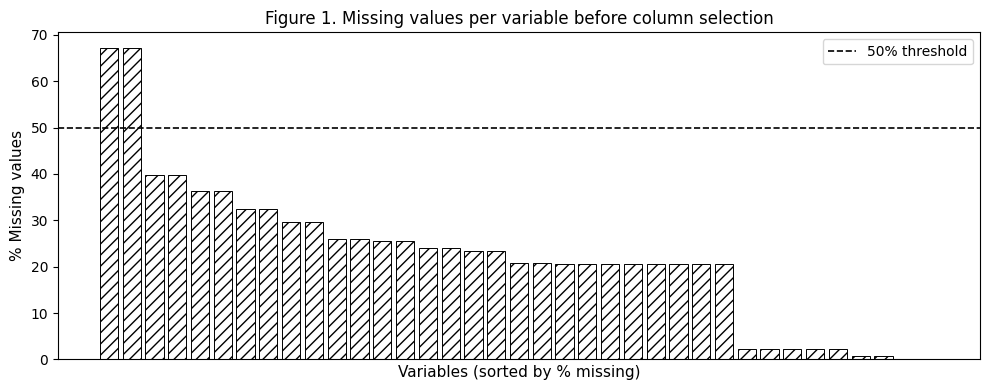

Variables with >50% NaN (protected variables): 2
Variables with any NaN: 37
Complete variables (0% NaN): 5


In [19]:
# --- Figure 1: Missing data before cleaning ---
na_pct_raw = df.isna().mean().sort_values(ascending=False) * 100
na_with_values = na_pct_raw[na_pct_raw > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(na_with_values)), na_with_values.values,
              color='white', edgecolor='black', linewidth=0.7)
for bar in bars:
    bar.set_hatch('///')
ax.axhline(50, color='black', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_xlabel('Variables (sorted by % missing)', fontsize=11)
ax.set_ylabel('% Missing values', fontsize=11)
ax.set_title('Figure 1. Missing values per variable before column selection', fontsize=12)
ax.set_xticks([])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Variables with >50% NaN (protected variables): {(na_pct_raw > 50).sum()}')
print(f'Variables with any NaN: {(na_pct_raw > 0).sum()}')
print(f'Complete variables (0% NaN): {(na_pct_raw == 0).sum()}')

In [21]:
df.corr(numeric_only=True).abs().style.format(precision=2).background_gradient(cmap='coolwarm')
##### no se si es asi

,Unnamed: 0,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Remates_totales_Local,Remates_totales_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Remates_fuera_Local,Remates_fuera_Visitante,Remates_rechazados_Local,Remates_rechazados_Visitante,Fueras_de_juego_Local,Fueras_de_juego_Visitante,Tiros_libres_Local,Tiros_libres_Visitante,Saques_de_banda_Local,Saques_de_banda_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante
Unnamed: 0,1.00,0.05,0.03,0.06,0.07,0.01,0.01,0.00,0.01,0.12,0.10,0.02,0.05,0.05,0.02,0.00,0.04,0.05,0.07,0.00,0.00,0.03,0.05,0.03,0.02,0.13,0.13,0.17,0.16
Goles_esperados_(xG)_Local,0.05,1.00,0.38,0.78,0.45,0.78,0.36,0.46,0.36,0.24,0.09,0.55,0.39,0.48,0.30,0.12,0.15,0.09,0.14,0.04,0.28,0.14,0.04,0.31,0.55,0.43,0.37,0.37,0.24
Goles_esperados_(xG)_Visitante,0.03,0.38,1.00,0.45,0.76,0.40,0.77,0.36,0.45,0.19,0.10,0.36,0.54,0.30,0.45,0.07,0.12,0.02,0.01,0.20,0.08,0.00,0.04,0.56,0.33,0.38,0.39,0.22,0.34
Remates_totales_Local,0.06,0.78,0.45,1.00,0.42,0.77,0.38,0.61,0.44,0.22,0.16,0.81,0.36,0.73,0.32,0.13,0.17,0.15,0.10,0.12,0.28,0.15,0.07,0.31,0.71,0.44,0.31,0.33,0.22
Remates_totales_Visitante,0.07,0.45,0.76,0.42,1.00,0.39,0.78,0.42,0.63,0.25,0.10,0.36,0.79,0.32,0.73,0.12,0.14,0.03,0.03,0.22,0.17,0.02,0.05,0.72,0.31,0.33,0.40,0.21,0.31
Remates_a_puerta_Local,0.01,0.78,0.40,0.77,0.39,1.00,0.33,0.46,0.37,0.21,0.10,0.43,0.33,0.35,0.26,0.13,0.15,0.13,0.05,0.02,0.24,0.09,0.09,0.25,0.87,0.38,0.34,0.30,0.21
Remates_a_puerta_Visitante,0.01,0.36,0.77,0.38,0.78,0.33,1.00,0.34,0.47,0.20,0.12,0.32,0.40,0.27,0.37,0.10,0.16,0.01,0.02,0.20,0.09,0.00,0.05,0.88,0.25,0.34,0.33,0.21,0.27
Córneres_Local,0.00,0.46,0.36,0.61,0.42,0.46,0.34,1.00,0.39,0.19,0.11,0.50,0.35,0.51,0.29,0.10,0.17,0.10,0.07,0.15,0.23,0.12,0.07,0.31,0.46,0.31,0.31,0.20,0.19
Córneres_Visitante,0.01,0.36,0.45,0.44,0.63,0.37,0.47,0.39,1.00,0.17,0.12,0.38,0.50,0.32,0.52,0.11,0.12,0.01,0.02,0.21,0.20,0.02,0.04,0.45,0.31,0.31,0.31,0.21,0.22
Tarjetas_amarillas_Local,0.12,0.24,0.19,0.22,0.25,0.21,0.20,0.19,0.17,1.00,0.14,0.16,0.18,0.17,0.19,0.04,0.03,0.09,0.29,0.00,0.08,0.32,0.07,0.17,0.16,0.13,0.19,0.11,0.15


In [23]:
# Definir la lista estricta de variables para el modelo
# Hemos quitado las que tenian mas de un 50% de nas en sus entradas
# Tambien hemos visto las que estaban altamente correlacionadas con otras
# Esto lo trataremos con la definicion de la siguiente lista, que omite varias features
columnas = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 
    'Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 
    'Posesión_Local', 'Posesión_Visitante', 
    # 'Remates_totales_Local', 'Remates_totales_Visitante', 
    'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 
    # 'Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 
    'Córneres_Local', 'Córneres_Visitante', 
    'Pases_Local', 'Pases_Visitante', 
    'Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante',
    # 'Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 
    # 'Fueras_de_juego_Local', 'Fueras_de_juego_Visitante', 
    # 'Tiros_libres_Local', 'Tiros_libres_Visitante', 
    # 'Pases_en_el_tercio_final_Local', 'Pases_en_el_tercio_final_Visitante', 
    # 'Saques_de_banda_Local', 'Saques_de_banda_Visitante', 
    'Faltas_Local', 'Faltas_Visitante', 
    # 'Entradas_Local', 'Entradas_Visitante', 
    # 'Duelos_ganados_Local', 'Duelos_ganados_Visitante', 
    'Paradas_Local', 'Paradas_Visitante',
    'Puntos_Local', 'Puntos_Visitante',
    #'Peso_Local', 'Peso_Visitante',
    'Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante'
]

# Filtrado mediante comprensión de listas
columnas_existentes = [col for col in columnas if col in df.columns]

# Sobrescribir el DataFrame con el subconjunto validado
df = df[columnas_existentes]

In [24]:
# Comprobar el dataset que hemos obtenido
pd.set_option('display.max_columns', None)
print(df.shape)
df.head()
df.describe()

(3144, 24)


,Fecha,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante
count,3144,1032.000000,1032.000000,2495.000000,2495.000000,2495.000000,2495.000000,2390.000000,2390.000000,2328.000000,2328.000000,2411.000000,2411.000000,3122.000000,3121.000000,3141.000000,3140.000000
mean,2023-09-28 15:34:21.068702,1.464564,1.125388,4.490982,3.647695,4.989980,4.030461,1.841841,2.054393,12.225086,12.278780,2.479469,2.973455,1330.970368,1321.980381,6.665954,6.212583
min,2019-06-06 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,726.030000,727.950000,0.000000,0.000000
25%,2022-01-30 00:00:00,0.670000,0.450000,2.000000,2.000000,3.000000,2.000000,1.000000,1.000000,9.000000,9.000000,1.000000,1.000000,1140.142500,1135.420000,0.297000,0.285000
50%,2024-03-21 00:00:00,1.250000,0.930000,4.000000,3.000000,4.000000,4.000000,2.000000,2.000000,12.000000,12.000000,2.000000,3.000000,1343.385000,1334.370000,1.380000,1.330000
75%,2025-03-20 00:00:00,2.030000,1.530000,6.000000,5.000000,7.000000,6.000000,3.000000,3.000000,15.000000,15.000000,4.000000,4.000000,1511.135000,1500.520000,7.640000,7.405000
max,2026-06-28 00:00:00,9.570000,6.340000,22.000000,25.000000,20.000000,20.000000,7.000000,11.000000,33.000000,37.000000,14.000000,15.000000,1901.480000,1901.480000,58.580000,58.580000
std,NaN,1.072548,0.898599,3.105957,2.713189,3.278001,2.895098,1.338207,1.392879,4.408456,4.513365,2.028401,2.245909,253.908292,248.866940,11.295491,10.847050


Datos como xG no están disponibles para fechas muy antiguas, por lo que vamos a quedarnos con partidos con fechas mas recientes

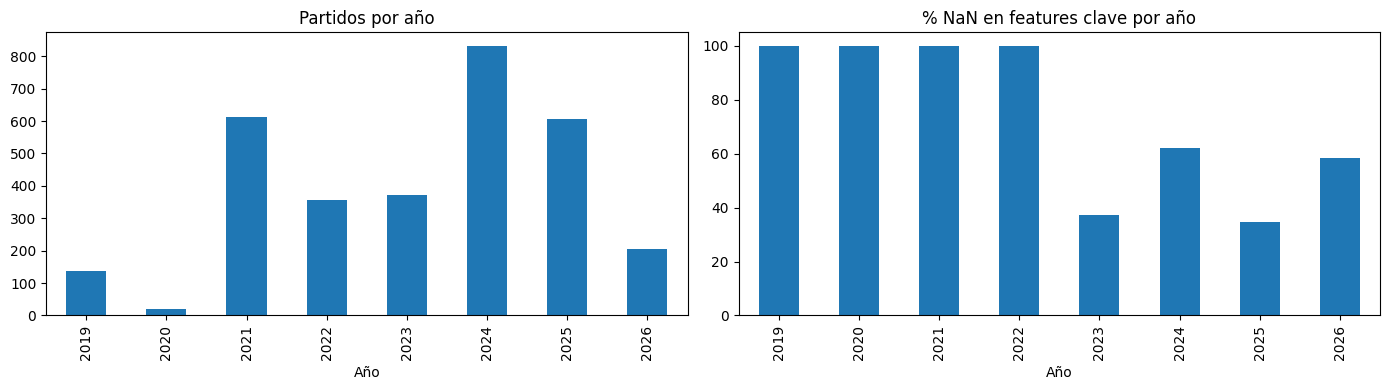

In [25]:
import matplotlib.pyplot as plt

# Partidos por año
df['Año'] = df['Fecha'].dt.year
conteo = df.groupby('Año').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Volumen de partidos por año
conteo.plot(kind='bar', ax=axes[0], title='Partidos por año')

# % de NaN en features clave por año (la justificación real)
features_clave = ['Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante']  # añade xG u otras si las tienes
pct_nans = df.groupby('Año')[features_clave].apply(lambda x: x.isna().mean().mean() * 100)
pct_nans.plot(kind='bar', ax=axes[1], title='% NaN en features clave por año')

plt.tight_layout()
plt.show()

In [26]:
# Cortamos fechas muy antiguas (poca info)
fecha_corte = pd.to_datetime('2023-01-01')
df = df[df['Fecha'] >= fecha_corte].copy()
print(df.shape)
df.head()

(2017, 25)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Pases_Local,Pases_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Año
1127,2023-03-23,Portugal,Liechtenstein,4-0Finalizado,4.16,0.03,71%,29%,11.0,1.0,12.0,0.0,91%(677/740),56%(91/162),NaN,NaN,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023
1128,2023-03-23,San Marino,Irlanda del Norte,0-2Finalizado,0.03,1.79,30%,70%,1.0,4.0,0.0,9.0,71%(205/287),87%(582/668),0.0,1.0,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023
1129,2023-03-23,Kazajistán,Eslovenia,1-2Finalizado,0.63,1.49,43%,57%,2.0,6.0,3.0,4.0,75%(225/301),86%(408/474),2.0,1.0,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023
1130,2023-03-23,Eslovaquia,Luxemburgo,0-0Finalizado,1.25,0.61,48%,52%,3.0,2.0,9.0,2.0,80%(321/401),78%(334/428),0.0,2.0,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023
1131,2023-03-23,Italia,Inglaterra,1-2Finalizado,1.16,2.07,49%,51%,1.0,4.0,7.0,3.0,81%(420/516),82%(318/389),3.0,5.0,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023


## Construcción de variables

Algunas variables vienen en formatos "raros" al hacer el scrapping. Por ejemplo, ``Pases_Local`` viene como `91%(814/897)`. Vamos a extraer los distintos datos para tener unas variables que podamos utilizar para la modelización.

### Limpieza del resultado

In [27]:
def limpiar_resultados_flashscore(texto):
    texto = str(texto).strip()
    
    # 1. Caso: Partido resuelto en 90 minutos (Ej: "2-1Finalizado")
    match_fin = re.match(r'^(\d+-\d+)\s*Finalizado', texto)
    if match_fin:
        resultado_90 = match_fin.group(1)
        return pd.Series([resultado_90, None, None])
        
    # 2. Caso: Partido resuelto en Prórroga (Ej: "1-0(0-0)Tras la prórroga")
    # Capturamos el 1-0 como final y el 0-0 como tiempo regular
    match_pro = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras la prórroga', texto)
    if match_pro:
        resultado_120 = match_pro.group(1) # El resultado final tras los 120 min (1-0)
        resultado_90 = match_pro.group(2)  # El resultado a los 90 min (0-0)
        
        # CORRECCIÓN: Asignamos el empate (0-0) como Resultado principal de los 90 min
        # y guardamos el 1-0 en la columna de Prórroga
        return pd.Series([resultado_90, resultado_120, None])
        
    # 3. Caso: Partido resuelto en Penaltis (Ej: "2-1(1-1)Tras los penaltis")
    match_pen = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras los penaltis', texto)
    if match_pen:
        resultado_penaltis = match_pen.group(1) # El resultado de la tanda (2-1)
        resultado_120 = match_pen.group(2)      # El resultado del partido jugado (1-1)
        
        # Asignamos el empate (1-1) como Resultado principal al haber sido tambien empate significan algo
        return pd.Series([resultado_120, resultado_120, resultado_penaltis])
    # Caso 4: Partido perdido por walkover (Ej: "0-3Por perdido")
    match_walkover = re.match(r'^(\d+-\d+)\s*Por perdido', texto)
    if match_walkover:
        return pd.Series([match_walkover.group(1), None, None])    
    # 5. Caso residual (aplazados, suspendidos, u otros textos)
    return pd.Series([texto, None, None])

# Aplicamos la función
nuevas_columnas = ['Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']
df[nuevas_columnas] = df['Resultado'].apply(limpiar_resultados_flashscore)
print(len(df))
print(df['Resultado'].isna().sum())
print(df[['Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']].head())
print(df['Resultado_Penaltis'].notna().sum(), "partidos a penaltis")
print(df['Resultado_Prorroga'].notna().sum(), "partidos con prórroga")
print(df['Resultado'].isna().sum(), "resultados sin parsear (caso residual)")

2017
0
     Resultado Resultado_Prorroga Resultado_Penaltis
1127       4-0                NaN                NaN
1128       0-2                NaN                NaN
1129       1-2                NaN                NaN
1130       0-0                NaN                NaN
1131       1-2                NaN                NaN
30 partidos a penaltis
42 partidos con prórroga
0 resultados sin parsear (caso residual)


### Limpieza de variables con (%)

In [28]:
# Especifica las columnas que tienen este formato complejo
columnas_combinadas = ['Pases_Local', 'Pases_Visitante'] 

for col in columnas_combinadas:
    extraccion = df[col].astype(str).str.extract(r'(\d+)%\((\d+)/\d+\)')
    
    # Creamos dos nuevas columnas a partir de la extracción y las pasamos a numérico.
    df[f"{col}_Pct"] = pd.to_numeric(extraccion[0], errors='coerce')
    df[f"{col}_Exitosos"] = pd.to_numeric(extraccion[1], errors='coerce')

# Opcional: Ver el resultado y borrar la columna original sucia
print(df[[f"{columnas_combinadas[0]}_Pct", f"{columnas_combinadas[0]}_Exitosos"]].head())

df = df.drop(columns=columnas_combinadas) # Descomenta esto si quieres borrar las originales

      Pases_Local_Pct  Pases_Local_Exitosos
1127             91.0                 677.0
1128             71.0                 205.0
1129             75.0                 225.0
1130             80.0                 321.0
1131             81.0                 420.0


In [29]:
# Lista con los nombres de las columnas que contienen porcentajes
columnas_porcentaje = ['Posesión_Local', 'Posesión_Visitante', 'Pases_Local_Pct', 'Pases_Visitante_Pct'] 

for col in columnas_porcentaje:
    df[col] = df[col].astype(str).str.replace('%', '').astype(float) 

# Verificamos el resultado
print(df[['Posesión_Local', 'Posesión_Visitante']].head())

      Posesión_Local  Posesión_Visitante
1127            71.0                29.0
1128            30.0                70.0
1129            43.0                57.0
1130            48.0                52.0
1131            49.0                51.0


## Filtro temporal

Eliminamos los partidos del propio Mundial 2026 (que son datos de test, no de entrenamiento) y nos quedamos solo con el historial previo para el análisis.

In [30]:
print(f"Filas totales originales: {len(df)}")

# Nos quedamos solo con los partidos previos al Mundial 2026
fecha_corte = pd.to_datetime('2026-06-11')
df = df[df['Fecha'] < fecha_corte].copy()

print(f"Filas para análisis: {len(df)}")

Filas totales originales: 2017
Filas para análisis: 1945


## Comprobación de nulos

In [31]:
# Variables con nulos
df.isnull().sum()

Fecha                                      0
Equipo_Local                               0
Equipo_Visitante                           0
Resultado                                  0
Goles_esperados_(xG)_Local               913
Goles_esperados_(xG)_Visitante           913
Posesión_Local                           317
Posesión_Visitante                       317
Remates_a_puerta_Local                   316
Remates_a_puerta_Visitante               316
Córneres_Local                           316
Córneres_Visitante                       316
Tarjetas_amarillas_Local                 386
Tarjetas_amarillas_Visitante             386
Faltas_Local                             369
Faltas_Visitante                         369
Paradas_Local                            400
Paradas_Visitante                        400
Puntos_Local                              21
Puntos_Visitante                          22
Valor_Mercado_Millones_Eur_Local           3
Valor_Mercado_Millones_Eur_Visitante       4
Año       

Consideramos la variable Posesión para eliminar filas con NAs. Esto se debe a que este es el dato más básico de estadísticas del partido. Si no tenemos este dato disponible, asumimos que no tendremos información útil para modelar y por tanto mejor obviar estas observaciones. 

In [32]:
# 1. Columnas que DEBEN estar completas
columnas_obligatorias = ['Posesión_Visitante', 'Posesión_Local'] 

# 2. Borramos las filas que tengan al menos un NA en las columnas obligatorias
df = df.dropna(subset=columnas_obligatorias)

# Reiniciar el índice tras borrar filas
df = df.reset_index(drop=True)

# Dataset restante tras eliminar filas con NAs en columnas críticas
print(df.shape)

# Check
df.isnull().sum()

(1628, 29)


Fecha                                      0
Equipo_Local                               0
Equipo_Visitante                           0
Resultado                                  0
Goles_esperados_(xG)_Local               596
Goles_esperados_(xG)_Visitante           596
Posesión_Local                             0
Posesión_Visitante                         0
Remates_a_puerta_Local                     0
Remates_a_puerta_Visitante                 0
Córneres_Local                             0
Córneres_Visitante                         0
Tarjetas_amarillas_Local                  71
Tarjetas_amarillas_Visitante              71
Faltas_Local                              53
Faltas_Visitante                          53
Paradas_Local                             84
Paradas_Visitante                         84
Puntos_Local                               7
Puntos_Visitante                           8
Valor_Mercado_Millones_Eur_Local           0
Valor_Mercado_Millones_Eur_Visitante       0
Año       

# Data Imputation

Para no quedarnos sin muestra, vamos a imputar los nulos utilizando la `IterativeImputer` de ``sklearn``. Esta es una opción avanzada, pero dado que la idea del Notebook es aprneder y divulgar utilizamos este método. 

Los parámetros no están optimizados al extremo, aquí buscamos simplemente tener un dataset completo y razonable sin buscar ser perfecto. 

In [33]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Separamos el dataset: columnas intocables (texto/identificadores) y columnas a imputar
columnas_texto = ['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis'] 
columnas_numericas = [col for col in df.columns if col not in columnas_texto]

# 2. Configuramos el Imputador
# Usamos RandomForest internamente porque capta muy bien las relaciones no lineales del fútbol
imputador = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42,
    min_value=0  # Nadie puede tener -2 remates o -0.5 xG
)

# 3. Entrenamos y aplicamos la imputación solo sobre las variables numéricas
df_imputado = pd.DataFrame(
    imputador.fit_transform(df[columnas_numericas]), 
    columns=columnas_numericas, 
    index=df.index
)

# 4. Volvemos a unir las columnas de texto intactas con los números ya limpios
df = pd.concat([df[columnas_texto], df_imputado], axis=1)

# Comprobación de que hemos aniquilado los NAs
print(df.isna().sum())

Fecha                                      0
Equipo_Local                               0
Equipo_Visitante                           0
Resultado                                  0
Resultado_Prorroga                      1589
Resultado_Penaltis                      1600
Goles_esperados_(xG)_Local                 0
Goles_esperados_(xG)_Visitante             0
Posesión_Local                             0
Posesión_Visitante                         0
Remates_a_puerta_Local                     0
Remates_a_puerta_Visitante                 0
Córneres_Local                             0
Córneres_Visitante                         0
Tarjetas_amarillas_Local                   0
Tarjetas_amarillas_Visitante               0
Faltas_Local                               0
Faltas_Visitante                           0
Paradas_Local                              0
Paradas_Visitante                          0
Puntos_Local                               0
Puntos_Visitante                           0
Valor_Merc

c:\Users\javie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Costurimos variables

In [ ]:
df[["Goles_Local", "Goles_Visitante"]] = df["Resultado"].str.split("-", expand=True)
df["Goles_Local"] = pd.to_numeric(df["Goles_Local"], errors="coerce")
df["Goles_Visitante"] = pd.to_numeric(df["Goles_Visitante"], errors="coerce")

# Target multiclase: 1=Local gana, X=Empate, 2=Visitante gana
df["Resultado_1X2"] = df.apply(lambda row: "1" if row["Goles_Local"] > row["Goles_Visitante"] 
                                         else ("X" if row["Goles_Local"] == row["Goles_Visitante"] else "2"), axis=1)

# Target continuo: diferencia de goles (para regresión)
df["Goles_diff"] = df["Goles_Local"] - df["Goles_Visitante"]

# Target binario: victoria local (1) o no (0)
df["Victoria_Local"] = (df["Goles_Local"] > df["Goles_Visitante"]).astype(int)

print(df['Resultado_1X2'].value_counts())
print(f"Victoria local rate: {df['Victoria_Local'].mean():.2%}")
df.head()

Resultado_1X2
1    705
2    526
X    397
Name: count, dtype: int64
Victoria local rate: 43.30%


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Año,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos,Goles_Local,Goles_Visitante,Resultado_1X2,Goles_diff,Victoria_Local
0,2023-03-23,Portugal,Liechtenstein,4-0,NaN,NaN,4.16,0.03,71.0,29.0,11.0,1.0,12.0,0.0,0.4,1.46,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023.0,91.0,677.0,56.0,91.0,4,0,1,4,1
1,2023-03-23,San Marino,Irlanda del Norte,0-2,NaN,NaN,0.03,1.79,30.0,70.0,1.0,4.0,0.0,9.0,0.0,1.00,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023.0,71.0,205.0,87.0,582.0,0,2,2,-2,0
2,2023-03-23,Kazajistán,Eslovenia,1-2,NaN,NaN,0.63,1.49,43.0,57.0,2.0,6.0,3.0,4.0,2.0,1.00,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023.0,75.0,225.0,86.0,408.0,1,2,2,-1,0
3,2023-03-23,Eslovaquia,Luxemburgo,0-0,NaN,NaN,1.25,0.61,48.0,52.0,3.0,2.0,9.0,2.0,0.0,2.00,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023.0,80.0,321.0,78.0,334.0,0,0,X,0,0
4,2023-03-23,Italia,Inglaterra,1-2,NaN,NaN,1.16,2.07,49.0,51.0,1.0,4.0,7.0,3.0,3.0,5.00,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023.0,81.0,420.0,82.0,318.0,1,2,2,-1,0


Vamos a construir variables de tipo "Share". Básicamente, del todal de disparos, que porcentaje fueron del local y cual del visitante. Estas variables suelen funcionar muy bien en deportes, y es que indica el "poder ofensivo" de un equipo no en términos absolutos si no relatvios dentro del partido. 

In [40]:
# Estructura: (Nombre Columna Local, Nombre Columna Visitante, Nombre para la nueva métrica)
pares_metricas = [
    ('Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'xG'),
    # ('Remates_totales_Local', 'Remates_totales_Visitante', 'Remates_Totales'),
    ('Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Remates_Puerta'),
    # ('Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 'Grandes_Ocasiones'),
    ('Córneres_Local', 'Córneres_Visitante', 'Corneres'),
    # ('Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 'Toques_Area_Rival'),
    # ('Duelos_ganados_Local', 'Duelos_ganados_Visitante', 'Duelos_Ganados'),
    ('Paradas_Local', 'Paradas_Visitante', 'Paradas'), # Nota: Un share alto aquí indica que fuiste dominado
    ('Pases_Local_Exitosos', 'Pases_Visitante_Exitosos', 'Pases_Exitosos'),
    # ('Pases_en_el_tercio_final_Local_Exitosos', 'Pases_en_el_tercio_final_Visitante_Exitosos', 'Pases_Tercio_Final'),
    # ('Entradas_Local_Exitosos', 'Entradas_Visitante_Exitosos', 'Entradas_Exitosas'),
    ('Goles_Local', 'Goles_Visitante', 'Goles'),
    ('Puntos_Local', 'Puntos_Visitante', 'Puntos'),
    ('Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante', 'Valor_Mercado_Millones_Eur')
]

for col_local, col_visitante, nombre_base in pares_metricas:
    # 1. Calculamos el volumen total de la métrica en el partido
    suma_total = df[col_local] + df[col_visitante]
    
    # 2. Calculamos el Share del Local
    # np.where(condición, valor_si_verdadero, valor_si_falso)
    df[f'{nombre_base}_Share_Local'] = np.where(
        suma_total > 0,
        df[col_local] / suma_total,
        0.5  # Asignamos 0.5 si la suma es 0 (ej: 0 goles de ambos = partido igualado)
    )
    
    # 3. El Share del Visitante es matemáticamente el inverso (1 - Local)
    df[f'{nombre_base}_Share_Visitante'] = 1 - df[f'{nombre_base}_Share_Local']

# Visualizamos una muestra de las nuevas columnas generadas
columnas_generadas = [f"{t[2]}_Share_Local" for t in pares_metricas]

# Check 
df[['Equipo_Local', 'Equipo_Visitante', 'Resultado'] + columnas_generadas].head()

,Equipo_Local,Equipo_Visitante,Resultado,xG_Share_Local,Remates_Puerta_Share_Local,Corneres_Share_Local,Paradas_Share_Local,Pases_Exitosos_Share_Local,Goles_Share_Local,Puntos_Share_Local,Valor_Mercado_Millones_Eur_Share_Local
0,Portugal,Liechtenstein,4-0,0.992840,0.916667,1.000000,0.125000,0.881510,1.000000,0.664437,0.999328
1,San Marino,Irlanda del Norte,0-2,0.016484,0.200000,0.000000,0.666667,0.260483,0.000000,0.353359,0.012521
2,Kazajistán,Eslovenia,1-2,0.297170,0.250000,0.428571,0.800000,0.355450,0.333333,0.455729,0.139555
3,Eslovaquia,Luxemburgo,0-0,0.672043,0.600000,0.818182,0.400000,0.490076,0.500000,0.533739,0.782579
4,Italia,Inglaterra,1-2,0.359133,0.200000,0.700000,1.000000,0.569106,0.333333,0.492762,0.207527


## Diferencias de estadísticas en crudo (Local - Visitante)

Para la nueva pregunta de investigación, las estadísticas del partido en sí son nuestras **variables de interés principal**. Creamos diferencias Local - Visitante para cada métrica: un valor positivo indica ventaja del equipo local.

A diferencia del objetivo original (predecir partidos futuros), aquí NO hay fuga de datos porque queremos precisamente analizar cómo las estadísticas del partido se relacionan con su resultado.

In [41]:
metricas_diff = [
    ('Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'xG_diff'),
    ('Posesión_Local', 'Posesión_Visitante', 'Posesion_diff'),
    ('Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Remates_puerta_diff'),
    ('Córneres_Local', 'Córneres_Visitante', 'Corneres_diff'),
    ('Pases_Local_Exitosos', 'Pases_Visitante_Exitosos', 'Pases_Exitosos_diff'),
    ('Pases_Local_Pct', 'Pases_Visitante_Pct', 'Pases_Pct_diff'),
    ('Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante', 'Tarjetas_diff'),
    ('Faltas_Local', 'Faltas_Visitante', 'Faltas_diff'),
    ('Paradas_Local', 'Paradas_Visitante', 'Paradas_diff'),
    ('Puntos_Local', 'Puntos_Visitante', 'FIFA_diff'),
    ('Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante', 'Valor_Mercado_diff'),
]

for col_local, col_visitante, nombre in metricas_diff:
    if col_local in df.columns and col_visitante in df.columns:
        df[nombre] = df[col_local] - df[col_visitante]
    else:
        print(f'AVISO: columna no encontrada para {nombre}')

cols_diff = [n for _, _, n in metricas_diff if n in df.columns]
print('Columnas de diferencia creadas:', cols_diff)
df[cols_diff].head()

Columnas de diferencia creadas: ['xG_diff', 'Posesion_diff', 'Remates_puerta_diff', 'Corneres_diff', 'Pases_Exitosos_diff', 'Pases_Pct_diff', 'Tarjetas_diff', 'Faltas_diff', 'Paradas_diff', 'FIFA_diff', 'Valor_Mercado_diff']


,xG_diff,Posesion_diff,Remates_puerta_diff,Corneres_diff,Pases_Exitosos_diff,Pases_Pct_diff,Tarjetas_diff,Faltas_diff,Paradas_diff,FIFA_diff,Valor_Mercado_diff
0,4.13,42.0,10.0,12.0,586.0,35.0,-1.06,-1.0,-6.0,842.70,38.644
1,-1.76,-40.0,-3.0,-9.0,-377.0,-16.0,-1.00,7.0,1.0,-633.40,-3.426
2,-0.86,-14.0,-4.0,-1.0,-183.0,-11.0,1.00,6.0,3.0,-225.97,-3.368
3,0.64,-4.0,1.0,7.0,-13.0,2.0,-2.00,-6.0,-1.0,180.23,1.661
4,-0.91,-2.0,-3.0,4.0,102.0,-1.0,-2.00,7.0,2.0,-50.63,-38.700


## Variables de control: calidad del equipo

Añadimos variables derivadas del ranking FIFA y valor de mercado como **controles de calidad del equipo**. Permiten aislar el efecto de las estadísticas de rendimiento en partido del nivel intrínseco de los equipos.

In [42]:
print(df.shape)
df.tail()


(1628, 61)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Año,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos,Goles_Local,Goles_Visitante,Resultado_1X2,Goles_diff,Victoria_Local,xG_Share_Local,xG_Share_Visitante,Remates_Puerta_Share_Local,Remates_Puerta_Share_Visitante,Corneres_Share_Local,Corneres_Share_Visitante,Paradas_Share_Local,Paradas_Share_Visitante,Pases_Exitosos_Share_Local,Pases_Exitosos_Share_Visitante,Goles_Share_Local,Goles_Share_Visitante,Puntos_Share_Local,Puntos_Share_Visitante,Valor_Mercado_Millones_Eur_Share_Local,Valor_Mercado_Millones_Eur_Share_Visitante,xG_diff,Posesion_diff,Remates_puerta_diff,Corneres_diff,Pases_Exitosos_diff,Pases_Pct_diff,Tarjetas_diff,Faltas_diff,Paradas_diff,FIFA_diff,Valor_Mercado_diff
1623,2026-05-28,Egipto,Rusia,1-0,NaN,NaN,1.1200,0.5200,54.0,46.0,4.0,1.0,5.0,6.0,1.00,2.0,13.00,19.00,1.00,3.00,1563.24,1525.60,4.480,7.350,2026.0,86.00,402.00,85.00,334.00,1,0,1,1,1,0.682927,0.317073,0.800000,0.200000,0.454545,0.545455,0.250000,0.750000,0.546196,0.453804,1.0,0.0,0.506093,0.493907,0.378698,0.621302,0.6000,8.0,3.0,-1.0,68.00,1.0,-1.00,-6.00,-2.00,37.64,-2.870
1624,2026-05-28,Irlanda,Catar,1-0,NaN,NaN,1.9000,0.4000,52.0,48.0,3.0,1.0,7.0,3.0,1.18,2.7,9.00,16.00,1.00,2.00,1436.63,1454.96,5.440,0.766,2026.0,87.00,392.00,88.00,358.00,1,0,1,1,1,0.826087,0.173913,0.750000,0.250000,0.700000,0.300000,0.333333,0.666667,0.522667,0.477333,1.0,0.0,0.496830,0.503170,0.876571,0.123429,1.5000,4.0,2.0,4.0,34.00,-1.0,-1.52,-7.00,-1.00,-18.33,4.674
1625,2026-05-29,Sudáfrica,Nicaragua,0-0,NaN,NaN,2.1800,0.0700,85.0,15.0,6.0,0.0,6.0,1.0,0.00,2.0,8.00,10.00,0.00,7.00,1429.73,1115.13,1.890,0.172,2026.0,92.00,616.00,56.00,65.00,0,0,X,0,0,0.968889,0.031111,1.000000,0.000000,0.857143,0.142857,0.000000,1.000000,0.904552,0.095448,0.5,0.5,0.561811,0.438189,0.916586,0.083414,2.1100,70.0,6.0,5.0,551.00,36.0,-2.00,-2.00,-7.00,314.60,1.718
1626,2026-05-29,Bosnia-Herzegovina,Macedonia del Norte,0-0,NaN,NaN,1.5462,0.6902,66.0,34.0,4.0,2.0,2.0,1.0,0.00,1.0,11.00,21.00,0.96,2.52,1385.84,1372.04,5.630,1.380,2026.0,92.00,621.00,79.00,257.00,0,0,X,0,0,0.691379,0.308621,0.666667,0.333333,0.666667,0.333333,0.275862,0.724138,0.707289,0.292711,0.5,0.5,0.502502,0.497498,0.803138,0.196862,0.8560,32.0,2.0,1.0,364.00,13.0,-1.00,-10.00,-1.56,13.80,4.250
1627,2026-05-29,Irak,Andorra,1-0,NaN,NaN,1.4008,0.6530,66.0,34.0,3.0,3.0,3.0,2.0,0.00,3.0,12.26,15.52,2.16,1.90,1447.14,945.34,0.815,0.137,2026.0,84.78,457.84,71.08,196.96,1,0,1,1,1,0.682053,0.317947,0.500000,0.500000,0.600000,0.400000,0.532020,0.467980,0.699206,0.300794,1.0,0.0,0.604870,0.395130,0.856092,0.143908,0.7478,32.0,0.0,1.0,260.88,13.7,-3.00,-3.26,0.26,501.80,0.678


In [119]:
print(df['Puntos_Local'].describe())
print(df['Puntos_Visitante'].describe())

count    1628.000000
mean     1354.954148
std       241.783089
min       726.030000
25%      1168.485000
50%      1362.670000
75%      1518.902500
max      1886.160000
Name: Puntos_Local, dtype: float64
count    1628.000000
mean     1341.941985
std       237.799436
min       727.950000
25%      1165.410000
50%      1345.040000
75%      1503.417500
max      1886.160000
Name: Puntos_Visitante, dtype: float64


In [43]:
# Diferencia de puntos FIFA
df['diff_Puntos_actual'] = df['Puntos_Local'] - df['Puntos_Visitante']

# ELO implicito a partir de los puntos ranking FIFA
df['Prob_Implicita_ELO'] = 1 / (1 + 10 ** (-df['diff_Puntos_actual'] / 400))


# Tiers según puntos fifa
# Tiers basados en cuantiles de la distribución real (todos los equipos, local+visitante)
todos_puntos = pd.concat([df['Puntos_Local'], df['Puntos_Visitante']])
q25, q50, q75 = todos_puntos.quantile([0.25, 0.5, 0.75])

print(f"Q25: {q25:.0f}, Q50: {q50:.0f}, Q75: {q75:.0f}")

def asignar_tier(puntos):
    if puntos >= q75: return 1
    elif puntos >= q50: return 2
    elif puntos >= q25: return 3
    else: return 4

df['diff_Tier'] = df['Puntos_Local'].apply(asignar_tier) - df['Puntos_Visitante'].apply(asignar_tier)

Q25: 1166, Q50: 1353, Q75: 1513


## Multicolinearidad

Hemos creado muchas variables y a partir de las mismas variables, por lo que tenemos riesgo de colinearidad. A pesar de que los modelos que utilizaremos pueden lidiar con esto, vamos a eliminar variables muy correladas para "limpiar" un poco nuestras variables ya que la muestra es relativamente pequeña. Además, así tendremos un modelo más interpretable y tenderemos un dataset que podríamos utilizar con otros modelos (e.g. regresión).

In [44]:
####################################
##### --- Multicolinearity (diagnóstico, sin dropeo) --- #####
####################################
exclude = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis', 'Resultado_1X2',
    'Goles_Local', 'Goles_Visitante', 'Goles_diff', 'Victoria_Local', 'Prob_Implicita_ELO'
]
covariables = [x for x in df.columns if x not in exclude and df[x].dtype != 'object']

corr_matrix = df[covariables].corr().abs()
threshold = 0.8
pares_correlacionados = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            pares_correlacionados.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"Pares con correlación > {threshold}: {len(pares_correlacionados)}")
for col_i, col_j, corr in sorted(pares_correlacionados, key=lambda x: -x[2]):
    print(f"  {col_i} <-> {col_j}: {corr:.3f}")

Pares con correlación > 0.8: 95
  xG_Share_Visitante <-> xG_Share_Local: 1.000
  Remates_Puerta_Share_Visitante <-> Remates_Puerta_Share_Local: 1.000
  Corneres_Share_Visitante <-> Corneres_Share_Local: 1.000
  Paradas_Share_Visitante <-> Paradas_Share_Local: 1.000
  Puntos_Share_Visitante <-> Puntos_Share_Local: 1.000
  Valor_Mercado_Millones_Eur_Share_Visitante <-> Valor_Mercado_Millones_Eur_Share_Local: 1.000
  diff_Puntos_actual <-> FIFA_diff: 1.000
  Pases_Exitosos_Share_Visitante <-> Pases_Exitosos_Share_Local: 1.000
  Goles_Share_Visitante <-> Goles_Share_Local: 1.000
  Posesion_diff <-> Posesión_Local: 1.000
  Posesion_diff <-> Posesión_Visitante: 1.000
  Posesión_Visitante <-> Posesión_Local: 1.000
  FIFA_diff <-> Puntos_Share_Visitante: 0.992
  diff_Puntos_actual <-> Puntos_Share_Visitante: 0.992
  FIFA_diff <-> Puntos_Share_Local: 0.992
  diff_Puntos_actual <-> Puntos_Share_Local: 0.992
  Pases_Exitosos_diff <-> Pases_Exitosos_Share_Local: 0.986
  Pases_Exitosos_diff <-> Pas

In [45]:
df_pares = pd.DataFrame(pares_correlacionados, columns=['var_1', 'var_2', 'corr']).sort_values('corr', ascending=False)
df_pares

,var_1,var_2,corr
13,xG_Share_Visitante,xG_Share_Local,1.000000
19,Corneres_Share_Visitante,Corneres_Share_Local,1.000000
18,Remates_Puerta_Share_Visitante,Remates_Puerta_Share_Local,1.000000
24,Paradas_Share_Visitante,Paradas_Share_Local,1.000000
90,diff_Puntos_actual,FIFA_diff,1.000000
...,...,...,...
58,Corneres_diff,Córneres_Visitante,0.804278
11,xG_Share_Local,Goles_esperados_(xG)_Visitante,0.804139
12,xG_Share_Visitante,Goles_esperados_(xG)_Visitante,0.804139
71,Pases_Pct_diff,Pases_Visitante_Pct,0.802784


In [123]:
print(df.shape)

(1628, 66)


## Guardar Datasets

In [46]:
print(df.shape)
df.head()

(1628, 64)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Valor_Mercado_Millones_Eur_Local,Valor_Mercado_Millones_Eur_Visitante,Año,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos,Goles_Local,Goles_Visitante,Resultado_1X2,Goles_diff,Victoria_Local,xG_Share_Local,xG_Share_Visitante,Remates_Puerta_Share_Local,Remates_Puerta_Share_Visitante,Corneres_Share_Local,Corneres_Share_Visitante,Paradas_Share_Local,Paradas_Share_Visitante,Pases_Exitosos_Share_Local,Pases_Exitosos_Share_Visitante,Goles_Share_Local,Goles_Share_Visitante,Puntos_Share_Local,Puntos_Share_Visitante,Valor_Mercado_Millones_Eur_Share_Local,Valor_Mercado_Millones_Eur_Share_Visitante,xG_diff,Posesion_diff,Remates_puerta_diff,Corneres_diff,Pases_Exitosos_diff,Pases_Pct_diff,Tarjetas_diff,Faltas_diff,Paradas_diff,FIFA_diff,Valor_Mercado_diff,diff_Puntos_actual,Prob_Implicita_ELO,diff_Tier
0,2023-03-23,Portugal,Liechtenstein,4-0,NaN,NaN,4.16,0.03,71.0,29.0,11.0,1.0,12.0,0.0,0.4,1.46,5.0,6.0,1.0,7.0,1702.54,859.84,38.670,0.026,2023.0,91.0,677.0,56.0,91.0,4,0,1,4,1,0.992840,0.007160,0.916667,0.083333,1.000000,0.000000,0.125000,0.875000,0.881510,0.118490,1.000000,0.000000,0.664437,0.335563,0.999328,0.000672,4.13,42.0,10.0,12.0,586.0,35.0,-1.06,-1.0,-6.0,842.70,38.644,842.70,0.992240,-3
1,2023-03-23,San Marino,Irlanda del Norte,0-2,NaN,NaN,0.03,1.79,30.0,70.0,1.0,4.0,0.0,9.0,0.0,1.00,16.0,9.0,2.0,1.0,763.15,1396.55,0.044,3.470,2023.0,71.0,205.0,87.0,582.0,0,2,2,-2,0,0.016484,0.983516,0.200000,0.800000,0.000000,1.000000,0.666667,0.333333,0.260483,0.739517,0.000000,1.000000,0.353359,0.646641,0.012521,0.987479,-1.76,-40.0,-3.0,-9.0,-377.0,-16.0,-1.00,7.0,1.0,-633.40,-3.426,-633.40,0.025428,2
2,2023-03-23,Kazajistán,Eslovenia,1-2,NaN,NaN,0.63,1.49,43.0,57.0,2.0,6.0,3.0,4.0,2.0,1.00,17.0,11.0,4.0,1.0,1163.09,1389.06,0.652,4.020,2023.0,75.0,225.0,86.0,408.0,1,2,2,-1,0,0.297170,0.702830,0.250000,0.750000,0.428571,0.571429,0.800000,0.200000,0.355450,0.644550,0.333333,0.666667,0.455729,0.544271,0.139555,0.860445,-0.86,-14.0,-4.0,-1.0,-183.0,-11.0,1.00,6.0,3.0,-225.97,-3.368,-225.97,0.214032,2
3,2023-03-23,Eslovaquia,Luxemburgo,0-0,NaN,NaN,1.25,0.61,48.0,52.0,3.0,2.0,9.0,2.0,0.0,2.00,11.0,17.0,2.0,3.0,1425.58,1245.35,2.300,0.639,2023.0,80.0,321.0,78.0,334.0,0,0,X,0,0,0.672043,0.327957,0.600000,0.400000,0.818182,0.181818,0.400000,0.600000,0.490076,0.509924,0.500000,0.500000,0.533739,0.466261,0.782579,0.217421,0.64,-4.0,1.0,7.0,-13.0,2.0,-2.00,-6.0,-1.0,180.23,1.661,180.23,0.738365,-1
4,2023-03-23,Italia,Inglaterra,1-2,NaN,NaN,1.16,2.07,49.0,51.0,1.0,4.0,7.0,3.0,3.0,5.00,13.0,6.0,2.0,0.0,1723.56,1774.19,13.730,52.430,2023.0,81.0,420.0,82.0,318.0,1,2,2,-1,0,0.359133,0.640867,0.200000,0.800000,0.700000,0.300000,1.000000,0.000000,0.569106,0.430894,0.333333,0.666667,0.492762,0.507238,0.207527,0.792473,-0.91,-2.0,-3.0,4.0,102.0,-1.0,-2.00,7.0,2.0,-50.63,-38.700,-50.63,0.427649,0


In [47]:
# Columnas del dataset final
print(df.columns.tolist())

['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis', 'Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'Posesión_Local', 'Posesión_Visitante', 'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Córneres_Local', 'Córneres_Visitante', 'Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante', 'Faltas_Local', 'Faltas_Visitante', 'Paradas_Local', 'Paradas_Visitante', 'Puntos_Local', 'Puntos_Visitante', 'Valor_Mercado_Millones_Eur_Local', 'Valor_Mercado_Millones_Eur_Visitante', 'Año', 'Pases_Local_Pct', 'Pases_Local_Exitosos', 'Pases_Visitante_Pct', 'Pases_Visitante_Exitosos', 'Goles_Local', 'Goles_Visitante', 'Resultado_1X2', 'Goles_diff', 'Victoria_Local', 'xG_Share_Local', 'xG_Share_Visitante', 'Remates_Puerta_Share_Local', 'Remates_Puerta_Share_Visitante', 'Corneres_Share_Local', 'Corneres_Share_Visitante', 'Paradas_Share_Local', 'Paradas_Share_Visitante', 'Pases_Exitosos_Share_Local', 'Pases_Exitosos_Share_Visitante

In [126]:
# Targets disponibles para el análisis
print('Targets:')
print('  Resultado_1X2:', df['Resultado_1X2'].value_counts().to_dict())
print('  Victoria_Local mean:', df['Victoria_Local'].mean().round(3))
print('  Goles_diff mean:', df['Goles_diff'].mean().round(3))

Targets:
  Resultado_1X2: {'1': 705, '2': 526, 'X': 397}
  Victoria_Local mean: 0.433
  Goles_diff mean: 0.364


In [127]:
# Guardamos el dataset limpio para el EDA y modelización
df.to_csv('./data/datos_limpios.csv', index=False)
print(f"Dataset guardado: {df.shape[0]} partidos, {df.shape[1]} columnas")

Dataset guardado: 1628 partidos, 66 columnas


In [128]:
# Resumen de features disponibles para el EDA
features_rendimiento = [c for c in df.columns if any(x in c for x in 
    ['xG', 'Posesion', 'Remates', 'Corner', 'Pases', 'Tarjetas', 'Falta', 'Paradas', '_diff', '_Share'])]
features_control = ['FIFA_diff', 'Valor_Mercado_diff', 'diff_Puntos_actual', 'Prob_Implicita_ELO', 'diff_Tier']
targets = ['Resultado_1X2', 'Victoria_Local', 'Goles_diff']

print(f'Features de rendimiento en partido: {len(features_rendimiento)}')
print(features_rendimiento)
print(f'\nControles de calidad de equipo: {[f for f in features_control if f in df.columns]}')
print(f'\nTargets: {targets}')

Features de rendimiento en partido: 42
['Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante', 'Faltas_Local', 'Faltas_Visitante', 'Paradas_Local', 'Paradas_Visitante', 'Pases_Local_Pct', 'Pases_Local_Exitosos', 'Pases_Visitante_Pct', 'Pases_Visitante_Exitosos', 'Goles_diff', 'xG_Share_Local', 'xG_Share_Visitante', 'Remates_Puerta_Share_Local', 'Remates_Puerta_Share_Visitante', 'Corneres_Share_Local', 'Corneres_Share_Visitante', 'Paradas_Share_Local', 'Paradas_Share_Visitante', 'Pases_Exitosos_Share_Local', 'Pases_Exitosos_Share_Visitante', 'Goles_Share_Local', 'Goles_Share_Visitante', 'Puntos_Share_Local', 'Puntos_Share_Visitante', 'Valor_Mercado_Millones_Eur_Share_Local', 'Valor_Mercado_Millones_Eur_Share_Visitante', 'xG_diff', 'Posesion_diff', 'Remates_puerta_diff', 'Corneres_diff', 'Pases_Exitosos_diff', 'Pases_Pct_diff', 'Tarjetas_diff', 'Faltas_diff', 'Para

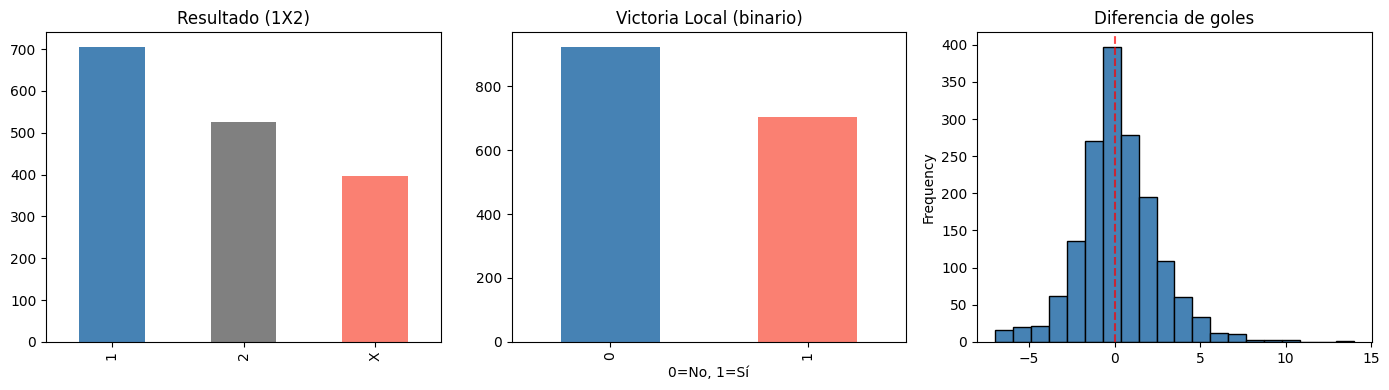

In [129]:
# Distribución de los targets
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Resultado 1X2
df['Resultado_1X2'].value_counts().plot(kind='bar', ax=axes[0], title='Resultado (1X2)', color=['steelblue','gray','salmon'])
axes[0].set_xlabel('')

# Victoria local
df['Victoria_Local'].value_counts().plot(kind='bar', ax=axes[1], title='Victoria Local (binario)', color=['steelblue','salmon'])
axes[1].set_xlabel('0=No, 1=Sí')

# Goles diff
df['Goles_diff'].plot(kind='hist', ax=axes[2], title='Diferencia de goles', bins=20, color='steelblue', edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
# Exploratory Data Analysis

The following analysis addresses the research question: **Which match performance statistics are the strongest predictors of football match outcomes?**

All figures use patterns (hatching, markers) to remain readable in black & white. Figures are numbered sequentially; tables are rounded to 3 decimal places.

### Table 2. Mean performance statistics by match outcome

Average values of key metric differences (Local − Visitante) grouped by match outcome (1 = home win, X = draw, 2 = away win). Positive values indicate a home team advantage.

In [130]:
# --- Table 2: Mean stats by outcome ---
stats_cols = ['xG_diff', 'Posesion_diff', 'Remates_puerta_diff',
              'Corneres_diff', 'Pases_Exitosos_diff', 'Paradas_diff']
stats_cols = [c for c in stats_cols if c in df.columns]

tabla = df.groupby('Resultado_1X2')[stats_cols].mean().round(3)
tabla.index.name = 'Outcome'
tabla.index = tabla.index.map({'1': '1 (Home win)', 'X': 'X (Draw)', '2': '2 (Away win)'})
tabla.columns = [c.replace('_diff', '') for c in tabla.columns]
print('Table 2. Mean performance metric differences by match outcome')
print(tabla.to_string())

# Also show match counts
print('\nMatch counts per outcome:')
print(df['Resultado_1X2'].map({'1': '1 (Home win)', 'X': 'X (Draw)', '2': '2 (Away win)'}).value_counts().sort_index().to_string())

Table 2. Mean performance metric differences by match outcome
                 xG  Posesion  Remates_puerta  Corneres  Pases_Exitosos  Paradas
Outcome                                                                         
1 (Home win)  1.300     0.146           3.950     2.668         146.771   -1.699
2 (Away win) -0.936    -0.094          -2.833    -0.859         -97.915    0.973
X (Draw)      0.144     0.021           0.481     0.542          14.542   -0.496

Match counts per outcome:
Resultado_1X2
1 (Home win)    705
2 (Away win)    526
X (Draw)        397


### Figure 2. Distribution of key performance statistics by match outcome

Box plots of performance metric differences (Local − Visitante) grouped by match outcome. A systematic shift across groups indicates predictive power. The dashed line marks zero (parity between teams).

/var/folders/c9/88zz0bpj7wx6d38dghnlklqh0000gn/T/ipykernel_29191/2986038009.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, patch_artist=True, labels=tick_labels,
/var/folders/c9/88zz0bpj7wx6d38dghnlklqh0000gn/T/ipykernel_29191/2986038009.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, patch_artist=True, labels=tick_labels,
/var/folders/c9/88zz0bpj7wx6d38dghnlklqh0000gn/T/ipykernel_29191/2986038009.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, patch_artist=True, labels=tick_labels,
/var/folders/c9/88zz0bpj7wx6d38dgh

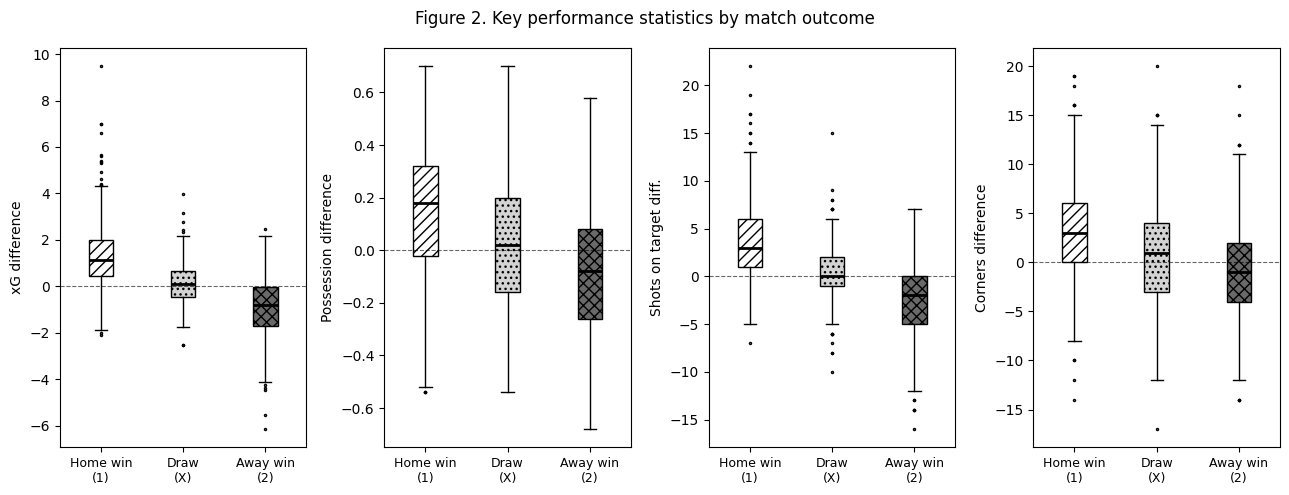

In [131]:
# --- Figure 2: Box plots by outcome ---
stats_plot = [
    ('xG_diff',           'xG difference'),
    ('Posesion_diff',      'Possession difference'),
    ('Remates_puerta_diff','Shots on target diff.'),
    ('Corneres_diff',      'Corners difference'),
]
stats_plot = [(c, l) for c, l in stats_plot if c in df.columns]

outcomes = ['1', 'X', '2']
tick_labels = ['Home win\n(1)', 'Draw\n(X)', 'Away win\n(2)']
hatches = ['///', '...', 'xxx']
facecolors = ['white', 'lightgray', 'dimgray']

fig, axes = plt.subplots(1, len(stats_plot), figsize=(13, 5))
if len(stats_plot) == 1:
    axes = [axes]

for ax, (col, ylabel) in zip(axes, stats_plot):
    data_groups = [df.loc[df['Resultado_1X2'] == o, col].dropna() for o in outcomes]
    bp = ax.boxplot(data_groups, patch_artist=True, labels=tick_labels,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', color='black', markersize=3))
    for patch, hatch, fc in zip(bp['boxes'], hatches, facecolors):
        patch.set_facecolor(fc)
        patch.set_hatch(hatch)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Figure 2. Key performance statistics by match outcome', fontsize=12)
plt.tight_layout()
plt.show()

### Figure 3. Correlation of match statistics with home team victory

Point-biserial correlation between each performance metric difference and the binary outcome *Victoria\_Local* (1 = home win, 0 = otherwise). Bars are ordered by absolute correlation; forward hatching (///) indicates positive association, back hatching (\\\\\\) indicates negative.

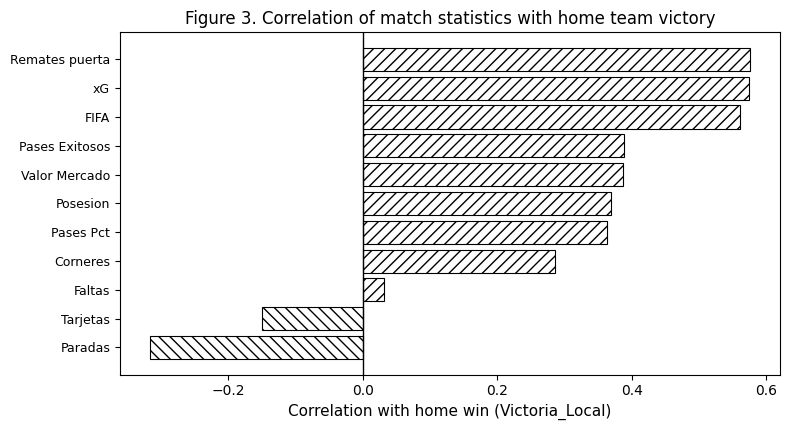

Top 5 predictors (absolute correlation):
Remates_puerta_diff    0.576
xG_diff                0.575
FIFA_diff              0.560
Pases_Exitosos_diff    0.388
Valor_Mercado_diff     0.386


In [132]:
# --- Figure 3: Correlations with Victoria_Local ---
diff_cols = [c for c in df.columns if c.endswith('_diff')
             and c not in ('Goles_diff',) and df[c].dtype != object]
corrs = (df[diff_cols + ['Victoria_Local']]
         .corr(numeric_only=True)['Victoria_Local']
         .drop('Victoria_Local')
         .dropna()
         .sort_values())

fig, ax = plt.subplots(figsize=(8, max(4, len(corrs) * 0.4)))
bars = ax.barh(range(len(corrs)), corrs.values,
               color='white', edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, corrs.values):
    bar.set_hatch('///' if val >= 0 else '\\\\\\')

ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels([c.replace('_diff', '').replace('_', ' ') for c in corrs.index], fontsize=9)
ax.set_xlabel('Correlation with home win (Victoria_Local)', fontsize=11)
ax.set_title('Figure 3. Correlation of match statistics with home team victory', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 5 predictors (absolute correlation):')
print(corrs.abs().sort_values(ascending=False).head(5).round(3).to_string())

### Figure 4. Expected goals difference vs. goal difference

Scatter plot of xG difference against goal difference by match outcome. xG measures the quality of chances created; strong alignment with actual goals validates its use as a predictor. Outcomes are differentiated by marker shape to maintain B&W readability.

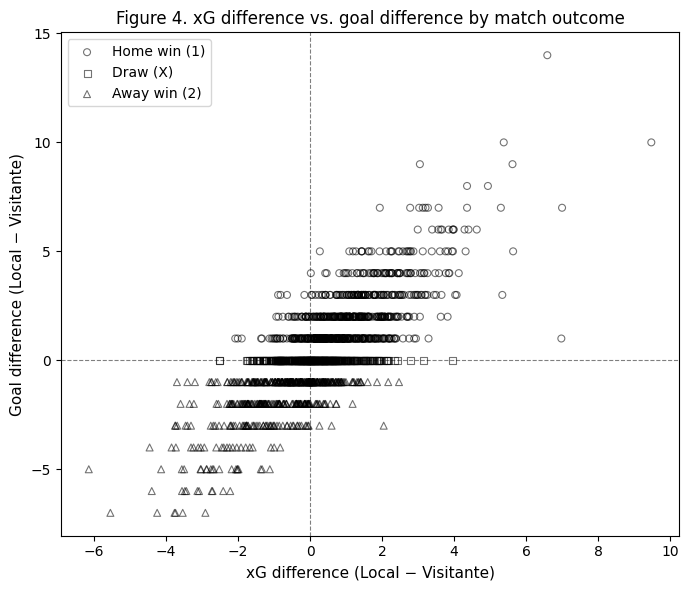

Pearson r (xG_diff vs Goles_diff): 0.781


In [133]:
# --- Figure 4: xG_diff vs Goles_diff ---
if 'xG_diff' in df.columns and 'Goles_diff' in df.columns:
    markers_map = {'1': 'o', 'X': 's', '2': '^'}
    labels_map  = {'1': 'Home win (1)', 'X': 'Draw (X)', '2': 'Away win (2)'}

    fig, ax = plt.subplots(figsize=(7, 6))
    for outcome, marker in markers_map.items():
        sub = df[df['Resultado_1X2'] == outcome].dropna(subset=['xG_diff', 'Goles_diff'])
        ax.scatter(sub['xG_diff'], sub['Goles_diff'],
                   marker=marker, s=25, alpha=0.55,
                   facecolors='none', edgecolors='black',
                   label=labels_map[outcome], linewidths=0.8)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('xG difference (Local − Visitante)', fontsize=11)
    ax.set_ylabel('Goal difference (Local − Visitante)', fontsize=11)
    ax.set_title('Figure 4. xG difference vs. goal difference by match outcome', fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    r = df[['xG_diff', 'Goles_diff']].corr().iloc[0, 1]
    print(f'Pearson r (xG_diff vs Goles_diff): {r:.3f}')

### Figure 5. Home win rate by xG difference quartile

Home win rate across quartiles of xG difference (Q1 = largest away advantage, Q4 = largest home advantage). A monotone increase across quartiles would confirm that xG is a reliable predictor of match outcome.

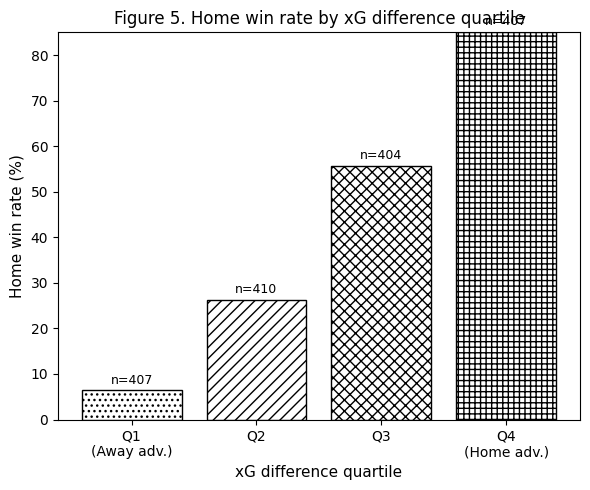

Table 3. Home win rate and match count by xG quartile
                 Win rate  Matches
xG_quartile                       
Q1\n(Away adv.)     0.064      407
Q2                  0.263      410
Q3                  0.557      404
Q4\n(Home adv.)     0.850      407


In [134]:
# --- Figure 5: Win rate by xG_diff quartile ---
if 'xG_diff' in df.columns:
    df_q = df[['xG_diff', 'Victoria_Local']].dropna().copy()
    df_q['xG_quartile'] = pd.qcut(df_q['xG_diff'], q=4,
                                   labels=['Q1\n(Away adv.)', 'Q2', 'Q3', 'Q4\n(Home adv.)'])
    wr = df_q.groupby('xG_quartile', observed=True)['Victoria_Local'].agg(['mean', 'count'])

    fig, ax = plt.subplots(figsize=(6, 5))
    hatches_q = ['...', '///', 'xxx', '+++']
    bars = ax.bar(range(len(wr)), wr['mean'] * 100,
                  color='white', edgecolor='black', linewidth=1)
    for bar, h in zip(bars, hatches_q):
        bar.set_hatch(h)
    for i, (rate, n) in enumerate(zip(wr['mean'], wr['count'])):
        ax.text(i, rate * 100 + 1.5, f'n={n}', ha='center', fontsize=9)

    ax.set_xticks(range(len(wr)))
    ax.set_xticklabels(wr.index, fontsize=10)
    ax.set_ylabel('Home win rate (%)', fontsize=11)
    ax.set_xlabel('xG difference quartile', fontsize=11)
    ax.set_title('Figure 5. Home win rate by xG difference quartile', fontsize=12)
    ax.set_ylim(0, 85)
    plt.tight_layout()
    plt.show()

    print('Table 3. Home win rate and match count by xG quartile')
    print(wr.rename(columns={'mean': 'Win rate', 'count': 'Matches'}).round(3).to_string())